# FLASHKNiFE measured-versus-simulated PDD figure maker

This notebook makes the publication layout for 9 and 6 MeV with the 10, 5, and 2 cm applicators. Each applicator has:

1. the measured and Geant4 PDD;
2. the dose difference, with a shaded ±5 percentage-point band; and
3. the 1D gamma index and pass rate.

The PNG is saved at **300 dpi**. The data use the confirmed measured arrays (`flash9` and `flash6alt`) and Geant4 runs 3001–3006. Simulated depths are the 0.5 mm voxel centres.

The difference is **Geant4 − measured**. The default unit is normalized-dose percentage points (pp), which stays well behaved in the low-dose tail. Gamma uses measured data as the reference.

> **Depth-shift note:** Keep all shifts at 0 mm for the unregistered validation result. If you use a manual or fitted shift, report the value and the alignment method. Do not present a post-hoc fitted result as an unshifted validation.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.grid": False,
    "axes.linewidth": 0.9,
    "savefig.facecolor": "white",
})

## 1. Settings — edit this cell

In [11]:
# ------------------------- FILES -------------------------
DATA_FILE = Path("FLASHKNiFE_PDD_input_data.csv")
OUTPUT_DIR = Path("pdd_figure_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PNG_NAME = "FLASHKNiFE_PDD_comparison_300dpi.png"
SVG_NAME = "FLASHKNiFE_PDD_comparison.svg"
SUMMARY_NAME = "FLASHKNiFE_PDD_comparison_summary.csv"
POINTWISE_NAME = "FLASHKNiFE_PDD_pointwise_comparison.csv"

# ---------------------- MAIN TITLE ------------------------
FIGURE_TITLE = "Measured and simulated percentage depth-dose curves"

# ------------------- MEASURED DEPTH SHIFT -----------------
# Positive = move the measured PDD to greater depth (right).
# Negative = move it towards the surface (left).
MEASURED_DEPTH_SHIFT_MM = {
    (9, 10): 0.0,
    (9, 5):  0.0,
    (9, 2):  0.0,
    (6, 10): 0.0,
    (6, 5):  0.0,
    (6, 2):  0.0,
}

# Optional automatic registration. Leave False for the formal unshifted result.
AUTO_OPTIMISE_SHIFT = True
AUTO_SHIFT_RANGE_MM = (-3.0, 3.0)
AUTO_SHIFT_STEP_MM = 0.05
AUTO_SHIFT_OBJECTIVE = "gamma"  # "gamma" or "rmse"

# ----------------------- GAMMA ----------------------------
GAMMA_DOSE_CRITERION_PCT = 2.0
GAMMA_DISTANCE_CRITERION_MM = 2.0
GAMMA_THRESHOLD_PCT = 10.0  # set 0.0 to include the full measured curve
GAMMA_SEARCH_STEP_MM = 0.025

# ------------------- DIFFERENCE PANEL ---------------------
# "percentage_points" is stable near the low-dose tail.
# "relative_percent" calculates 100*(simulation-measurement)/measurement.
DIFFERENCE_MODE = "percentage_points"
DIFFERENCE_BAND = 5.0
DIFFERENCE_YLIM = (-15.0, 15.0)
GAMMA_YLIM = (0.0, 3.0)

# ----------------------- AXES -----------------------------
DEPTH_XLIM_MM = (0.0, 70.0)
PDD_YLIM = (0.0, 105.0)
MAJOR_X_TICK_MM = 10.0
MINOR_X_TICK_MM = 5.0

# ------------------- LINE THICKNESS -----------------------
MEASURED_LINEWIDTH = 1.5
SIMULATION_LINEWIDTH = 1.8
DIFFERENCE_LINEWIDTH = 1.25
GAMMA_LINEWIDTH = 1.25
MARKER_SIZE = 3.0
AXIS_LINEWIDTH = 0.9

# ------------------- OUTPUT QUALITY -----------------------
DPI = 300
FIGURE_SIZE_INCHES = (15.5, 11.5)

# Okabe-Ito colour-blind-safe palette.
COLOURS = {
    "measured": "#0072B2",      # blue
    "simulated": "#D55E00",     # vermillion
    "difference": "#009E73",    # bluish green
    "gamma": "#CC79A7",         # reddish purple
    "reference": "#4D4D4D",     # dark grey
}

## 2. Load and check the measured and simulated data

In [12]:
data = pd.read_csv(DATA_FILE)

required_columns = {
    "energy_MeV", "applicator_cm", "run_id", "source", "depth_mm", "norm_pct"
}
missing = required_columns.difference(data.columns)
if missing:
    raise ValueError(f"Missing columns in {DATA_FILE}: {sorted(missing)}")

data["source"] = data["source"].replace({"Geant4": "simulated"})
expected_cases = [(9, 10), (9, 5), (9, 2), (6, 10), (6, 5), (6, 2)]

for energy, applicator in expected_cases:
    case = data.query("energy_MeV == @energy and applicator_cm == @applicator")
    sources = set(case["source"])
    if sources != {"measured", "simulated"}:
        raise ValueError(
            f"{energy} MeV, {applicator} cm has sources {sources}; "
            "expected measured and simulated."
        )

print(data.groupby(["energy_MeV", "applicator_cm", "source"]).size())

energy_MeV  applicator_cm  source   
6           2              measured     167
                           simulated    160
            5              measured      44
                           simulated    160
            10             measured      44
                           simulated    160
9           2              measured      29
                           simulated    160
            5              measured      44
                           simulated    160
            10             measured      44
                           simulated    160
dtype: int64


## 3. Analysis functions

In [13]:
def get_curve(energy, applicator, source):
    curve = (
        data.query(
            "energy_MeV == @energy and applicator_cm == @applicator and source == @source"
        )[["depth_mm", "norm_pct"]]
        .dropna()
        .sort_values("depth_mm")
        .copy()
    )
    if curve["depth_mm"].duplicated().any():
        curve = curve.groupby("depth_mm", as_index=False)["norm_pct"].mean()
    curve["norm_pct"] = 100.0 * curve["norm_pct"] / curve["norm_pct"].max()
    return curve.reset_index(drop=True)


def interpolate_with_nan(x_new, x, y):
    return np.interp(x_new, x, y, left=np.nan, right=np.nan)


def gamma_1d(measured, simulated):
    # Global 1D gamma with measured data as the reference.
    sim_x = simulated["depth_mm"].to_numpy(float)
    sim_y = simulated["norm_pct"].to_numpy(float)
    search_x = np.arange(
        sim_x.min(), sim_x.max() + GAMMA_SEARCH_STEP_MM / 2, GAMMA_SEARCH_STEP_MM
    )
    search_y = np.interp(search_x, sim_x, sim_y)

    rows = []
    for depth, dose in measured[["depth_mm", "norm_pct"]].itertuples(index=False):
        inside = search_x.min() <= depth <= search_x.max()
        included = bool(inside and dose >= GAMMA_THRESHOLD_PCT)
        gamma = np.nan
        if included:
            gamma = np.min(
                np.sqrt(
                    ((search_x - depth) / GAMMA_DISTANCE_CRITERION_MM) ** 2
                    + ((search_y - dose) / GAMMA_DOSE_CRITERION_PCT) ** 2
                )
            )
        rows.append((depth, dose, gamma, included))

    result = pd.DataFrame(
        rows, columns=["depth_mm", "measured_norm_pct", "gamma", "included"]
    )
    result["pass"] = np.where(
        result["included"], result["gamma"] <= 1.0, np.nan
    )
    return result


def compare_curves(measured, simulated):
    sim_at_measured = interpolate_with_nan(
        measured["depth_mm"].to_numpy(float),
        simulated["depth_mm"].to_numpy(float),
        simulated["norm_pct"].to_numpy(float),
    )
    pointwise = measured.rename(columns={"norm_pct": "measured_norm_pct"}).copy()
    pointwise["simulated_norm_pct"] = sim_at_measured
    pointwise["difference_percentage_points"] = (
        pointwise["simulated_norm_pct"] - pointwise["measured_norm_pct"]
    )
    denominator = pointwise["measured_norm_pct"].replace(0.0, np.nan)
    pointwise["relative_percent_difference"] = (
        100.0 * pointwise["difference_percentage_points"] / denominator
    )

    valid = pointwise["simulated_norm_pct"].notna()
    threshold = pointwise["measured_norm_pct"] >= GAMMA_THRESHOLD_PCT
    metric_mask = valid & threshold
    error = pointwise.loc[metric_mask, "difference_percentage_points"].to_numpy()
    rmse = float(np.sqrt(np.mean(error**2))) if len(error) else np.nan
    mae = float(np.mean(np.abs(error))) if len(error) else np.nan

    gamma = gamma_1d(measured, simulated)
    included_gamma = gamma.loc[gamma["included"], "gamma"].dropna()
    pass_rate = (
        100.0 * float(np.mean(included_gamma <= 1.0)) if len(included_gamma) else np.nan
    )
    return pointwise, gamma, rmse, mae, pass_rate


def shifted_measured_curve(energy, applicator, shift_mm):
    measured = get_curve(energy, applicator, "measured")
    measured["depth_mm"] = measured["depth_mm"] + float(shift_mm)
    return measured


def optimise_shift(energy, applicator, simulated):
    candidates = np.arange(
        AUTO_SHIFT_RANGE_MM[0],
        AUTO_SHIFT_RANGE_MM[1] + AUTO_SHIFT_STEP_MM / 2,
        AUTO_SHIFT_STEP_MM,
    )
    trials = []
    for shift in candidates:
        measured = shifted_measured_curve(energy, applicator, shift)
        _, _, rmse, _, pass_rate = compare_curves(measured, simulated)
        trials.append((float(shift), rmse, pass_rate))

    trials = pd.DataFrame(trials, columns=["shift_mm", "rmse", "gamma_pass_rate"])
    if AUTO_SHIFT_OBJECTIVE == "gamma":
        best = trials.sort_values(
            ["gamma_pass_rate", "rmse", "shift_mm"],
            ascending=[False, True, True],
        ).iloc[0]
    elif AUTO_SHIFT_OBJECTIVE == "rmse":
        best = trials.sort_values(
            ["rmse", "gamma_pass_rate", "shift_mm"],
            ascending=[True, False, True],
        ).iloc[0]
    else:
        raise ValueError('AUTO_SHIFT_OBJECTIVE must be "gamma" or "rmse"')
    return float(best["shift_mm"]), trials


def style_axis(ax, show_x_labels=True):
    ax.set_xlim(*DEPTH_XLIM_MM)
    ax.xaxis.set_major_locator(MultipleLocator(MAJOR_X_TICK_MM))
    ax.xaxis.set_minor_locator(MultipleLocator(MINOR_X_TICK_MM))
    ax.tick_params(
        which="major", direction="in", length=5, width=AXIS_LINEWIDTH,
        top=True, right=True, labelbottom=show_x_labels,
    )
    ax.tick_params(
        which="minor", direction="in", length=3, width=0.75 * AXIS_LINEWIDTH,
        top=True, right=True,
    )
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_LINEWIDTH)

## 4. Build the six-panel figure and save the results

,energy_MeV,applicator_cm,run_id,shift_source,applied_measured_shift_mm,unshifted_RMSE_percentage_points,displayed_RMSE_percentage_points,unshifted_MAE_percentage_points,displayed_MAE_percentage_points,unshifted_gamma_pass_percent,displayed_gamma_pass_percent,gamma_dose_criterion_percent,gamma_distance_criterion_mm,gamma_threshold_percent
0,9,10,3001,auto-gamma,-0.95,2.334,1.236,1.603,0.997,100.000,100.0,2.0,2.0,10.0
1,9,5,3002,auto-gamma,-0.55,4.809,3.719,3.391,2.744,82.051,100.0,2.0,2.0,10.0
2,9,2,3003,auto-gamma,2.75,6.198,0.551,4.509,0.465,56.000,100.0,2.0,2.0,10.0
3,6,10,3004,auto-gamma,0.20,1.531,1.282,1.238,0.941,96.774,100.0,2.0,2.0,10.0
4,6,5,3005,auto-gamma,-0.55,2.590,1.511,2.053,1.154,100.000,100.0,2.0,2.0,10.0
5,6,2,3006,auto-gamma,1.95,3.700,4.978,2.961,3.896,85.714,100.0,2.0,2.0,10.0


Saved 300 dpi PNG: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_comparison_300dpi.png
Saved vector figure: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_comparison.svg
Saved summary: pdd_figure_outputs/FLASHKNiFE_PDD_comparison_summary.csv
Saved pointwise data: pdd_figure_outputs/FLASHKNiFE_PDD_pointwise_comparison.csv


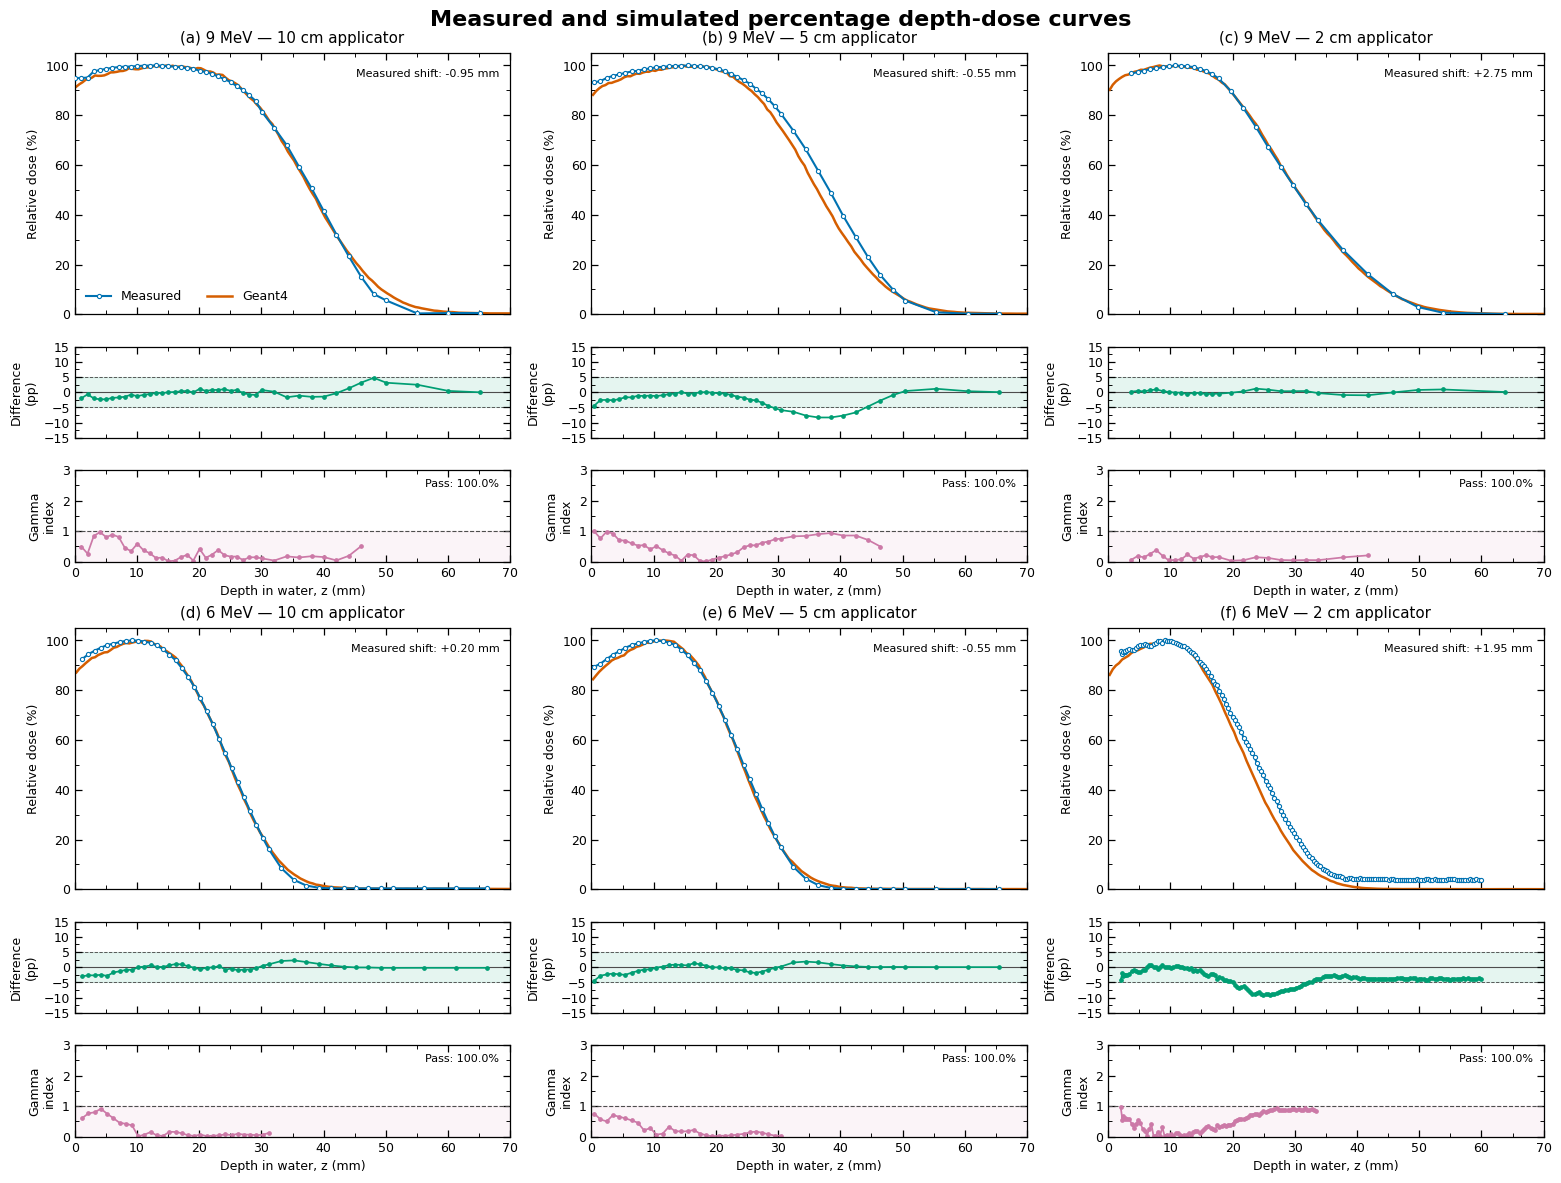

In [14]:
fig = plt.figure(figsize=FIGURE_SIZE_INCHES, constrained_layout=True)
outer = fig.add_gridspec(2, 3, wspace=0.12, hspace=0.14)

summary_rows = []
pointwise_frames = []
panel_letters = iter("abcdef")

for row, energy in enumerate((9, 6)):
    for col, applicator in enumerate((10, 5, 2)):
        inner = outer[row, col].subgridspec(
            3, 1, height_ratios=(3.2, 1.12, 1.12), hspace=0.05
        )
        ax_pdd = fig.add_subplot(inner[0])
        ax_diff = fig.add_subplot(inner[1], sharex=ax_pdd)
        ax_gamma = fig.add_subplot(inner[2], sharex=ax_pdd)

        simulated = get_curve(energy, applicator, "simulated")
        run_id = int(
            data.query(
                "energy_MeV == @energy and applicator_cm == @applicator"
            )["run_id"].iloc[0]
        )

        manual_shift = float(MEASURED_DEPTH_SHIFT_MM[(energy, applicator)])
        shift_source = "manual"
        if AUTO_OPTIMISE_SHIFT:
            applied_shift, _ = optimise_shift(energy, applicator, simulated)
            shift_source = f"auto-{AUTO_SHIFT_OBJECTIVE}"
        else:
            applied_shift = manual_shift

        measured_unshifted = shifted_measured_curve(energy, applicator, 0.0)
        measured = shifted_measured_curve(energy, applicator, applied_shift)

        _, _, rmse_unshifted, mae_unshifted, gamma_unshifted = compare_curves(
            measured_unshifted, simulated
        )
        pointwise, gamma, rmse, mae, gamma_pass = compare_curves(measured, simulated)

        pointwise.insert(0, "applied_measured_shift_mm", applied_shift)
        pointwise.insert(0, "run_id", run_id)
        pointwise.insert(0, "applicator_cm", applicator)
        pointwise.insert(0, "energy_MeV", energy)
        pointwise_frames.append(pointwise)

        summary_rows.append({
            "energy_MeV": energy,
            "applicator_cm": applicator,
            "run_id": run_id,
            "shift_source": shift_source,
            "applied_measured_shift_mm": applied_shift,
            "unshifted_RMSE_percentage_points": rmse_unshifted,
            "displayed_RMSE_percentage_points": rmse,
            "unshifted_MAE_percentage_points": mae_unshifted,
            "displayed_MAE_percentage_points": mae,
            "unshifted_gamma_pass_percent": gamma_unshifted,
            "displayed_gamma_pass_percent": gamma_pass,
            "gamma_dose_criterion_percent": GAMMA_DOSE_CRITERION_PCT,
            "gamma_distance_criterion_mm": GAMMA_DISTANCE_CRITERION_MM,
            "gamma_threshold_percent": GAMMA_THRESHOLD_PCT,
        })

        # Main PDD graph.
        ax_pdd.plot(
            measured["depth_mm"], measured["norm_pct"],
            color=COLOURS["measured"], linewidth=MEASURED_LINEWIDTH,
            marker="o", markersize=MARKER_SIZE, markerfacecolor="white",
            markeredgewidth=0.8, label="Measured", zorder=3,
        )
        ax_pdd.plot(
            simulated["depth_mm"], simulated["norm_pct"],
            color=COLOURS["simulated"], linewidth=SIMULATION_LINEWIDTH,
            label="Geant4", zorder=2,
        )
        ax_pdd.set_ylim(*PDD_YLIM)
        ax_pdd.yaxis.set_major_locator(MultipleLocator(20))
        ax_pdd.yaxis.set_minor_locator(MultipleLocator(10))
        ax_pdd.set_ylabel("Relative dose (%)")
        ax_pdd.set_title(
            f"({next(panel_letters)}) {energy} MeV — {applicator} cm applicator",
            pad=7,
        )
        ax_pdd.text(
            0.975, 0.94, f"Measured shift: {applied_shift:+.2f} mm",
            transform=ax_pdd.transAxes, ha="right", va="top", fontsize=8,
        )
        style_axis(ax_pdd, show_x_labels=False)
        if row == 0 and col == 0:
            ax_pdd.legend(loc="lower left", frameon=False, ncol=2)

        # Difference graph.
        difference_column = (
            "difference_percentage_points"
            if DIFFERENCE_MODE == "percentage_points"
            else "relative_percent_difference"
        )
        ax_diff.axhspan(
            -DIFFERENCE_BAND, DIFFERENCE_BAND,
            color=COLOURS["difference"], alpha=0.10, zorder=0,
        )
        ax_diff.axhline(0, color=COLOURS["reference"], linewidth=0.8, zorder=1)
        ax_diff.axhline(
            DIFFERENCE_BAND, color=COLOURS["reference"],
            linestyle="--", linewidth=0.65, zorder=1,
        )
        ax_diff.axhline(
            -DIFFERENCE_BAND, color=COLOURS["reference"],
            linestyle="--", linewidth=0.65, zorder=1,
        )
        ax_diff.plot(
            pointwise["depth_mm"], pointwise[difference_column],
            color=COLOURS["difference"], linewidth=DIFFERENCE_LINEWIDTH,
            marker="o", markersize=0.80 * MARKER_SIZE,
        )
        ax_diff.set_ylim(*DIFFERENCE_YLIM)
        ax_diff.yaxis.set_major_locator(MultipleLocator(5))
        ax_diff.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax_diff.set_ylabel("Difference\n(pp)" if DIFFERENCE_MODE == "percentage_points" else "Difference\n(%)")
        style_axis(ax_diff, show_x_labels=False)

        # Gamma graph.
        plotted_gamma = gamma.loc[gamma["included"]].copy()
        ax_gamma.axhspan(0, 1, color=COLOURS["gamma"], alpha=0.08, zorder=0)
        ax_gamma.axhline(
            1.0, color=COLOURS["reference"], linestyle="--", linewidth=0.8
        )
        ax_gamma.plot(
            plotted_gamma["depth_mm"], plotted_gamma["gamma"],
            color=COLOURS["gamma"], linewidth=GAMMA_LINEWIDTH,
            marker="o", markersize=0.80 * MARKER_SIZE,
        )
        ax_gamma.set_ylim(*GAMMA_YLIM)
        ax_gamma.yaxis.set_major_locator(MultipleLocator(1))
        ax_gamma.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax_gamma.set_ylabel("Gamma\nindex")
        ax_gamma.set_xlabel("Depth in water, z (mm)")
        ax_gamma.text(
            0.975, 0.90, f"Pass: {gamma_pass:.1f}%",
            transform=ax_gamma.transAxes, ha="right", va="top", fontsize=8,
        )
        style_axis(ax_gamma, show_x_labels=True)

fig.suptitle(FIGURE_TITLE, fontsize=16, fontweight="bold", y=1.015)

png_path = OUTPUT_DIR / PNG_NAME
svg_path = OUTPUT_DIR / SVG_NAME
fig.savefig(png_path, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(svg_path, bbox_inches="tight", facecolor="white")

summary = pd.DataFrame(summary_rows)
pointwise_output = pd.concat(pointwise_frames, ignore_index=True)
summary.to_csv(OUTPUT_DIR / SUMMARY_NAME, index=False, float_format="%.6f")
pointwise_output.to_csv(OUTPUT_DIR / POINTWISE_NAME, index=False, float_format="%.6f")

display(summary.round(3))
print(f"Saved 300 dpi PNG: {png_path.resolve()}")
print(f"Saved vector figure: {svg_path.resolve()}")
print(f"Saved summary: {OUTPUT_DIR / SUMMARY_NAME}")
print(f"Saved pointwise data: {OUTPUT_DIR / POINTWISE_NAME}")
plt.show()

## How to move a measured PDD

Edit `MEASURED_DEPTH_SHIFT_MM` in the settings cell and run all cells again.

```python
MEASURED_DEPTH_SHIFT_MM[(9, 5)] = +0.50  # move the 9 MeV, 5 cm measured PDD 0.5 mm deeper
MEASURED_DEPTH_SHIFT_MM[(6, 2)] = -0.25  # move the 6 MeV, 2 cm measured PDD 0.25 mm shallower
```

For an exploratory fitted alignment, set `AUTO_OPTIMISE_SHIFT = True`. The summary always stores both the unshifted and displayed RMSE, MAE, and gamma pass rates so the effect of registration stays visible.